In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

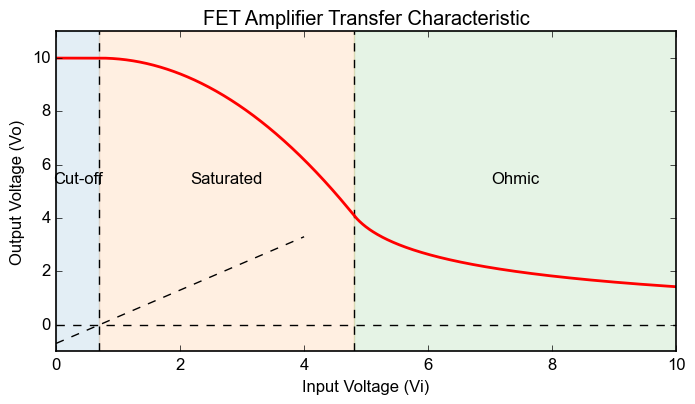

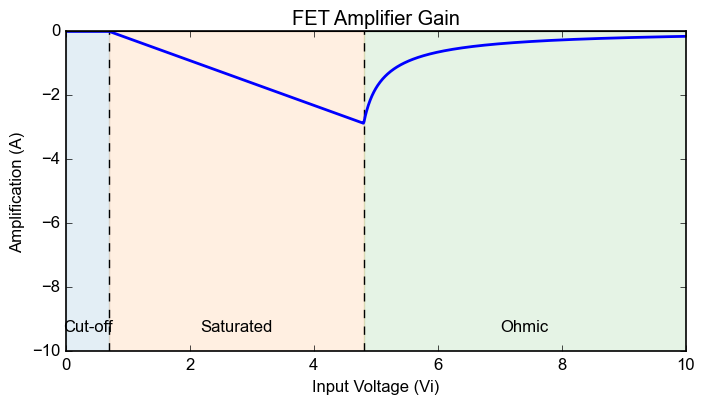

In [30]:
Vdd = 10
Rd = 1000
Vt = 0.7
alpha = 0.0007
Vimax = Vt + (np.sqrt(1 + 2 * alpha * Rd * Vdd) - 1) / (alpha * Rd)



Vi = np.linspace(0, 10, 1000)

Vo = np.empty_like(Vi)

mask_low = Vi < Vt
mask_mid = (Vi >= Vt) & (Vi < Vimax)
mask_high = Vi >= Vimax

Vo[mask_low] = Vdd
Vo[mask_mid] = Vdd - 0.5 * alpha * Rd * (Vi[mask_mid] - Vt) ** 2
Vo[mask_high] = (1 / (alpha * Rd) + (Vi[mask_high] - Vt)) * (
    1
    - np.sqrt(
        1 - (2 * alpha * Rd * Vdd) / (1 + alpha * Rd * (Vi[mask_high] - Vt)) ** 2
    )
)

plt.figure(figsize=(8, 4))
plt.axvspan(0, Vt, color='tab:blue', alpha=0.12)
plt.axvspan(Vt, Vimax, color='tab:orange', alpha=0.12)
plt.axvspan(Vimax, 10, color='tab:green', alpha=0.12)
plt.axvline(Vt, color='black', linestyle='--', linewidth=1)
plt.axvline(Vimax, color='black', linestyle='--', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.plot([0, 4], [-Vt, 4 - Vt], color='black', linestyle='--', linewidth=1)
plt.plot(Vi, Vo, lw=2, color='red', zorder=2)
plt.text(Vt / 2, 5.75, 'Cut-off', ha='center', va='top')
plt.text((Vt + Vimax) / 2, 5.75, 'Saturated', ha='center', va='top')
plt.text((Vimax + 10) / 2, 5.75, 'Ohmic', ha='center', va='top')
plt.xlabel('Input Voltage (Vi)')
plt.ylabel('Output Voltage (Vo)')
plt.xlim(0, 10)
plt.ylim(-1, 11)
plt.title('FET Amplifier Transfer Characteristic')
plt.show()

A = np.diff(Vo) / np.diff(Vi)
Vi_A = 0.5 * (Vi[:-1] + Vi[1:])

plt.figure(figsize=(8, 4))
plt.axvspan(0, Vt, color='tab:blue', alpha=0.12)
plt.axvspan(Vt, Vimax, color='tab:orange', alpha=0.12)
plt.axvspan(Vimax, 10, color='tab:green', alpha=0.12)
plt.axvline(Vt, color='black', linestyle='--', linewidth=1)
plt.axvline(Vimax, color='black', linestyle='--', linewidth=1)
plt.plot(Vi_A, A, lw=2, color='blue')
plt.text(Vt / 2, -9, 'Cut-off', ha='center', va='top')
plt.text((Vt + Vimax) / 2, -9, 'Saturated', ha='center', va='top')
plt.text((Vimax + 10) / 2, -9, 'Ohmic', ha='center', va='top')
plt.xlabel('Input Voltage (Vi)')
plt.ylabel('Amplification (A)')
plt.xlim(0, 10)
plt.ylim(-10, 0)
plt.title('FET Amplifier Gain')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

In [31]:
print(Vimax)
Amax = np.min(A)
Amax_theo = -(np.sqrt(1 + 2 * alpha * Rd * Vdd) - 1) 
print(Amax)
print(Amax_theo)

4.804261923153454
-2.869705498282232
-2.872983346207417


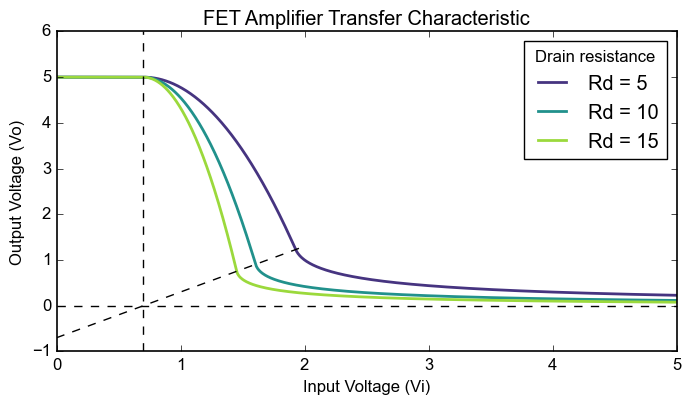

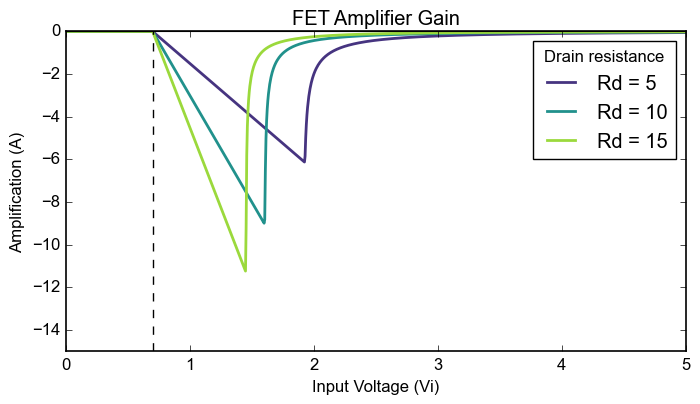

In [32]:
Vdd = 5
Vt = 0.7
alpha = 1
Rd_values = [5, 10, 15]
reference_Rd = 10

Vi = np.linspace(0, 5, 1000)

plt.figure(figsize=(8, 4))
reference_Vimax = None
reference_Vo = None

for Rd, color in zip(Rd_values, plt.cm.viridis(np.linspace(0.15, 0.85, len(Rd_values)))):
    Vimax = Vt + (np.sqrt(1 + 2 * alpha * Rd * Vdd) - 1) / (alpha * Rd)

    Vo = np.empty_like(Vi)
    mask_low = Vi < Vt
    mask_mid = (Vi >= Vt) & (Vi < Vimax)
    mask_high = Vi >= Vimax

    Vo[mask_low] = Vdd
    Vo[mask_mid] = Vdd - 0.5 * alpha * Rd * (Vi[mask_mid] - Vt) ** 2
    Vo[mask_high] = (1 / (alpha * Rd) + (Vi[mask_high] - Vt)) * (
        1
        - np.sqrt(
            1 - (2 * alpha * Rd * Vdd) / (1 + alpha * Rd * (Vi[mask_high] - Vt)) ** 2
        )
    )

    plt.plot(Vi, Vo, lw=2, color=color, label=f'Rd = {Rd}')

    if Rd == reference_Rd:
        reference_Vimax = Vimax
        reference_Vo = Vo.copy()

plt.axvline(Vt, color='black', linestyle='--', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.plot([0, 2], [-Vt, 2 - Vt], color='black', linestyle='--', linewidth=1)
plt.xlabel('Input Voltage (Vi)')
plt.ylabel('Output Voltage (Vo)')
plt.xlim(0, 5)
plt.ylim(-1, 6)
plt.title('FET Amplifier Transfer Characteristic')
plt.legend(title='Drain resistance')
plt.show()

A = np.diff(reference_Vo) / np.diff(Vi)
Vi_A = 0.5 * (Vi[:-1] + Vi[1:])
Vimax = reference_Vimax

plt.figure(figsize=(8, 4))
reference_A = None
reference_Vi_A = None

for Rd, color in zip(Rd_values, plt.cm.viridis(np.linspace(0.15, 0.85, len(Rd_values)))):
    Vimax = Vt + (np.sqrt(1 + 2 * alpha * Rd * Vdd) - 1) / (alpha * Rd)
    Vo = np.empty_like(Vi)
    mask_low = Vi < Vt
    mask_mid = (Vi >= Vt) & (Vi < Vimax)
    mask_high = Vi >= Vimax

    Vo[mask_low] = Vdd
    Vo[mask_mid] = Vdd - 0.5 * alpha * Rd * (Vi[mask_mid] - Vt) ** 2
    Vo[mask_high] = (1 / (alpha * Rd) + (Vi[mask_high] - Vt)) * (
        1
        - np.sqrt(
            1 - (2 * alpha * Rd * Vdd) / (1 + alpha * Rd * (Vi[mask_high] - Vt)) ** 2
        )
    )

    A_curve = np.diff(Vo) / np.diff(Vi)
    Vi_A_curve = 0.5 * (Vi[:-1] + Vi[1:])
    plt.plot(Vi_A_curve, A_curve, lw=2, color=color, label=f'Rd = {Rd}')

    if Rd == reference_Rd:
        reference_A = A_curve.copy()
        reference_Vi_A = Vi_A_curve.copy()

plt.axvline(Vt, color='black', linestyle='--', linewidth=1)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Input Voltage (Vi)')
plt.ylabel('Amplification (A)')
plt.xlim(0, 5)
plt.ylim(-15, 0)
plt.title('FET Amplifier Gain')
plt.legend(title='Drain resistance')
plt.show()

A = reference_A
Vi_A = reference_Vi_A
Vimax = reference_Vimax
Rd = reference_Rd